# Pole-to-Chromosome 1 and 2 mean plot script
## Make a mean plots for all the data from the pole-to-chromosome distance of the two side of the spindle and output as `.png` or `.svg` 

In [1]:
# library packages
import os
import csv
import glob
import math
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# input folder 
file_path = "D:/data/Analysis Data/python_analysis/input"
# data_files = os.listdir(file_path)

# output folder
folder_save = "D:/data/Analysis Data/python_analysis/output"

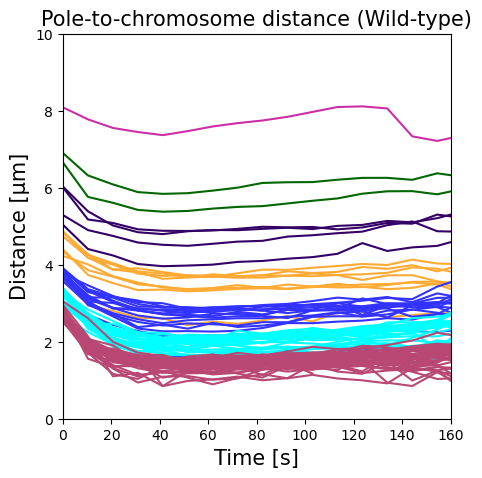

In [3]:
# create a dictionary of colors
colors = {'1-cell': '#CC2EA5', 
          '2-cell': '#006600', 
         '4-cell': '#330066',
         '8-cell': '#FFAA33',
         '16-cell': '#3333FF',
         '32-cell': '#00FFFF',
         '64-cell': '#b84873'}

# colors = {'2-cell': '#006600', 
#          '4-cell': '#330066',
#          '8-cell': '#FFAA33',
#          '16-cell': '#3333FF',
#          '32-cell': '#00FFFF',
#          '64-cell': '#b84873'}

# define a function which takes in 3 parameters which will be computed in a for loop for making
# a combine polts of the Pole-to-chromosome distance.
def plotPoleChromosome(cellname, df, ax1):

    # create a list of each of the binary cell stage for both sides of the pole-to-chromosome
   
    # cell_pc1 = [columnname for columnname in df if columnname.startswith(cellname) and columnname.endswith('pc1')]
    # cell_pc2 = [columnname for columnname in df if columnname.startswith(cellname) and columnname.endswith('pc2')]
    
    # cell_pc1 = [columnname for columnname in df if columnname.startswith(cellname)]
    # cell_pc2 = [columnname for columnname in df if columnname.startswith(cellname)]
    
    cell_pc = [columnname for columnname in df if columnname.startswith(cellname)]
    
    # plt.figure(figsize=(6,6))
    plt.rcParams.update({'figure.max_open_warning': 0}) # ignore warning message on the number of files opened
    
    # make the primary plot
    for column in cell_pc:
        ax1 = sns.lineplot(data=df, x='time', y=column, alpha=1, color=colors[cellname])

    # plot features
    ax1.axes.set_title('Pole-to-chromosome distance (Wild-type)', fontsize=15)
    # ax1.axes.set_title('Pole-to-chromosome distance\nSmall embryo (ani2-RNAi)', fontsize=15)
    ax1.set_xlabel("Time [s]",fontsize=15)
    ax1.set_ylabel("Distance [μm]",fontsize=15)
    ax1.set(ylim=(0, 10), 
            xlim=(-0, 150), 
            xticks=(np.arange(-0, 160+20, step=20)), 
            yticks=(np.arange(0, 10+2, step=2)))
    
    # make the secondary plots
    # for column in cell_pc2:
    #     ax1 = sns.lineplot(data=df, x='time', y=column, alpha=1, color=colors[cellname], linestyle="dotted", ax=ax1)    
    return ax1

# define the shape and size of the plot
plt.figure(figsize=(5,5))
ax1 = None

# read into the path directory of the files
with os.scandir(file_path) as data_files:
    for i in data_files:
        
        # read out the files from the folder
        df = pd.read_csv(i, index_col=None)
        
        # call the function and add the characteristic color for each of the data plot
        for cellname in colors.keys():
            ax1 = plotPoleChromosome(cellname, df, ax1)
            
# save to different folder
ax1.figure.savefig(os.path.join(folder_save, 'Avg_PC.png'), dpi=600)
ax1.figure.savefig(os.path.join(folder_save, 'Avg_PC.svg'))

# ax1.figure.savefig(os.path.join(folder_save, 'Avg_PC_mean_fit_values.png'), dpi=600)
# ax1.figure.savefig(os.path.join(folder_save, 'Avg_PC_mean_fit_values.svg'))
        